# 簡單圖像分類器

此筆記本將向您展示如何使用預訓練的神經網絡進行圖像分類。

**您將學到：**
- 如何載入並使用預訓練模型
- 圖像預處理
- 對圖像進行預測
- 理解信心分數

**使用案例：** 識別圖像中的物體（例如「貓」、「狗」、「車」等）

---


## 第一步：匯入所需的庫

讓我們匯入所需的工具。不用擔心，如果你現在還不完全理解這些！


In [1]:
# Core libraries
import numpy as np
from PIL import Image
import requests
from io import BytesIO

# TensorFlow for deep learning
try:
    import tensorflow as tf
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
    print("✅ TensorFlow loaded successfully!")
    print(f"   Version: {tf.__version__}")
except ImportError:
    print("❌ Please install TensorFlow: pip install tensorflow")

✅ TensorFlow loaded successfully!
   Version: 2.20.0


## 步驟 2：載入預訓練模型

我們將使用 **MobileNetV2**，這是一個已經在數百萬張圖片上訓練過的神經網絡。

這被稱為 **遷移學習**——使用別人訓練好的模型！


In [2]:
print("📦 Loading pre-trained MobileNetV2 model...")
print("   This may take a minute on first run (downloading weights)...")

# Load the model
# include_top=True means we use the classification layer
# weights='imagenet' means it was trained on ImageNet dataset
model = MobileNetV2(weights='imagenet', include_top=True)

print("✅ Model loaded!")
print(f"   The model can recognize 1000 different object categories")

📦 Loading pre-trained MobileNetV2 model...
   This may take a minute on first run (downloading weights)...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model loaded!
   The model can recognize 1000 different object categories


## 第 3 步：輔助函式

讓我們建立一些函式來載入並準備影像，以供我們的模型使用。


In [3]:
def load_image_from_url(url):
    """
    Load an image from a URL.

    Args:
        url: Web address of the image

    Returns:
        PIL Image object
    """
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    return img


def prepare_image(img):
    """
    Prepare an image for the model.

    Steps:
    1. Resize to 224x224 (model's expected size)
    2. Convert to array
    3. Add batch dimension
    4. Preprocess for MobileNetV2

    Args:
        img: PIL Image

    Returns:
        Preprocessed image array
    """
    # Resize to 224x224 pixels
    img = img.resize((224, 224))

    # Convert to numpy array
    img_array = np.array(img)

    # Add batch dimension (model expects multiple images)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for MobileNetV2
    img_array = preprocess_input(img_array)

    return img_array


def classify_image(img):
    """
    Classify an image and return top predictions.

    Args:
        img: PIL Image

    Returns:
        List of (class_name, confidence) tuples
    """
    # Prepare the image
    img_array = prepare_image(img)

    # Make prediction
    predictions = model.predict(img_array, verbose=0)

    # Decode predictions to human-readable labels
    # top=5 means we get the top 5 most likely classes
    decoded = decode_predictions(predictions, top=5)[0]

    # Convert to simpler format
    results = [(label, float(confidence)) for (_, label, confidence) in decoded]

    return results


print("✅ Helper functions ready!")

✅ Helper functions ready!


## 第四步：使用範例圖片進行測試

讓我們嘗試分類一些來自網路的圖片吧！


In [4]:
# Sample images to classify
# These are from Unsplash (free stock photos)
test_images = [
    {
        "url": "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
        "description": "A cat"
    },
    {
        "url": "https://images.unsplash.com/photo-1552053831-71594a27632d?w=400",
        "description": "A dog"
    },
    {
        "url": "https://images.unsplash.com/photo-1511919884226-fd3cad34687c?w=400",
        "description": "A car"
    },
]

print(f"🧪 Testing on {len(test_images)} images...")
print("=" * 70)

🧪 Testing on 3 images...


### 將每張圖片分類



📸 Image 1: A cat
----------------------------------------------------------------------


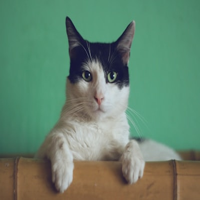

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🎯 Top 5 Predictions:
  1. Egyptian_cat         13.57% ██████
  2. tabby                10.72% █████
  3. Siamese_cat           5.60% ██
  4. tiger_cat             5.34% ██
  5. carton                4.86% ██

📸 Image 2: A dog
----------------------------------------------------------------------


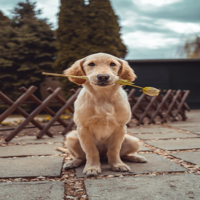


🎯 Top 5 Predictions:
  1. golden_retriever     57.78% ████████████████████████████
  2. Saluki                6.27% ███
  3. Labrador_retriever    3.06% █
  4. cocker_spaniel        1.07% 
  5. redbone               0.94% 

📸 Image 3: A car
----------------------------------------------------------------------


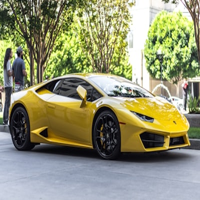


🎯 Top 5 Predictions:
  1. sports_car           77.11% ██████████████████████████████████████
  2. racer                10.64% █████
  3. car_wheel             3.33% █
  4. passenger_car         0.21% 
  5. convertible           0.20% 



In [5]:
for i, img_data in enumerate(test_images, 1):
    print(f"\n📸 Image {i}: {img_data['description']}")
    print("-" * 70)

    try:
        # Load image
        img = load_image_from_url(img_data['url'])

        # Display image
        display(img.resize((200, 200)))  # Show smaller version

        # Classify
        results = classify_image(img)

        # Show predictions
        print("\n🎯 Top 5 Predictions:")
        for rank, (label, confidence) in enumerate(results, 1):
            # Create a visual bar
            bar_length = int(confidence * 50)
            bar = "█" * bar_length

            print(f"  {rank}. {label:20s} {confidence*100:5.2f}% {bar}")

    except Exception as e:
        print(f"❌ Error: {e}")

print("\n" + "=" * 70)

## 第五步：嘗試使用自己的圖片！

將下面的 URL 替換為您想要分類的任何圖片 URL。


🖼️  Classifying your custom image...


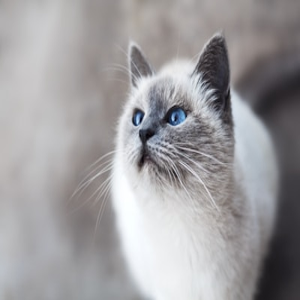


🎯 Top 5 Predictions:
----------------------------------------------------------------------
  1. Siamese_cat          59.95% █████████████████████████████
  2. Egyptian_cat          5.27% ██
  3. tabby                 3.08% █
  4. lynx                  3.07% █
  5. Persian_cat           1.77% 


🏆 Best guess: Siamese_cat (59.95% confident)


In [9]:
# Try your own image!
# Replace this URL with any image URL
# custom_image_url = "https://images.unsplash.com/photo-1472491235688-bdc81a63246e?w=400"  # A flower

custom_image_url = "https://unsplash.com/photos/white-and-brown-long-fur-cat-ZCHj_2lJP00?w=400"  # A flower

print("🖼️  Classifying your custom image...")
print("=" * 70)

try:
    # Load and show image
    img = load_image_from_url(custom_image_url)
    display(img.resize((300, 300)))

    # Classify
    results = classify_image(img)

    # Show results
    print("\n🎯 Top 5 Predictions:")
    print("-" * 70)
    for rank, (label, confidence) in enumerate(results, 1):
        bar_length = int(confidence * 50)
        bar = "█" * bar_length
        print(f"  {rank}. {label:20s} {confidence*100:5.2f}% {bar}")

    # Highlight top prediction
    top_label, top_confidence = results[0]
    print("\n" + "=" * 70)
    print(f"\n🏆 Best guess: {top_label} ({top_confidence*100:.2f}% confident)")

except Exception as e:
    print(f"❌ Error: {e}")
    print("   Make sure the URL points to a valid image!")

## 💡 剛剛發生了什麼？

1. **我們載入了一個預訓練模型** - MobileNetV2 已經在數百萬張圖片上進行過訓練  
2. **我們對圖片進行了預處理** - 將圖片調整大小並格式化以適配模型  
3. **模型進行了預測** - 輸出了對 1000 個物件類別的概率  
4. **我們解碼了結果** - 將數字轉換為人類可讀的標籤  

### 理解信心分數

- **90-100%**：非常有信心（幾乎肯定正確）  
- **70-90%**：有信心（可能正確）  
- **50-70%**：信心一般（可能正確）  
- **低於 50%**：信心不足（不確定）  

### 為什麼預測可能會出錯？

- **不尋常的角度或光線** - 模型是在典型照片上訓練的  
- **多個物件** - 模型預期只有一個主要物件  
- **罕見物件** - 模型只認識 1000 個類別  
- **低品質圖片** - 模糊或像素化的圖片更難辨識  

---


## 🚀 下一步

1. **嘗試不同的圖片：**
   - 在 [Unsplash](https://unsplash.com) 找圖片
   - 右鍵 → 「複製圖片地址」以獲取 URL

2. **試驗：**
   - 抽象藝術會有什麼效果？
   - 它能否辨識不同角度的物體？
   - 它如何處理多個物體？

3. **深入了解：**
   - 探索 [電腦視覺課程](../lessons/4-ComputerVision/README.md)
   - 學習如何訓練自己的圖片分類器
   - 理解 CNN（卷積神經網絡）的工作原理

---

## 🎉 恭喜！

你剛剛使用最先進的神經網絡建造了一個圖片分類器！

這項技術同樣應用於：
- Google Photos（整理你的照片）
- 自駕車（辨識物體）
- 醫療診斷（分析 X 光片）
- 品質控制（檢測缺陷）

繼續探索和學習吧！🚀



---

**免責聲明**：  
本文件已使用 AI 翻譯服務 [Co-op Translator](https://github.com/Azure/co-op-translator) 進行翻譯。儘管我們努力確保翻譯的準確性，但請注意，自動翻譯可能包含錯誤或不準確之處。原始文件的母語版本應被視為權威來源。對於關鍵資訊，建議使用專業人工翻譯。我們對因使用此翻譯而引起的任何誤解或錯誤解釋不承擔責任。
